斜率: -0.730


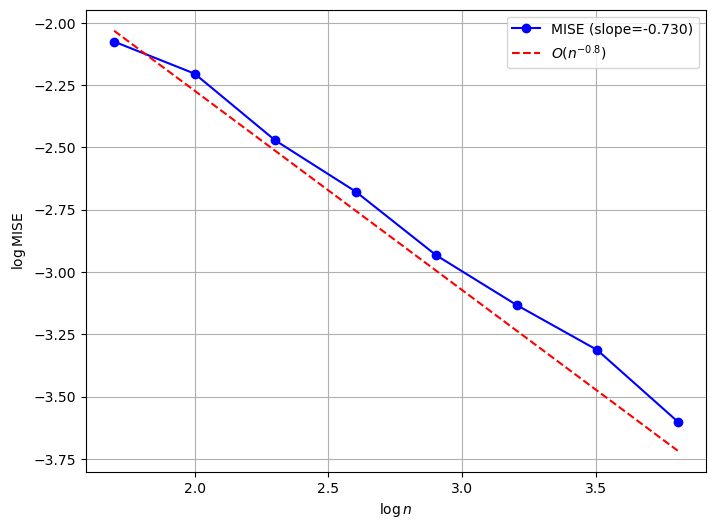

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde
from scipy.stats import linregress
np.random.seed(42)

samples = np.array([50, 100, 200, 400, 800, 1600, 3200, 6400]) # 样本量
trials = 100 # 模拟次数

grid = np.linspace(-5, 5, 1000)
dx = grid[1] - grid[0]
density = norm.pdf(grid) # 真实密度函数 N(0,1)

mises = []
for n in samples:
    ises = []
    for _ in range(trials):
        data = np.random.normal(0, 1, n)
        kde = gaussian_kde(data)
        estimated = kde.evaluate(grid) # 核密度估计
        ise = np.sum((estimated - density)**2) * dx 
        ises.append(ise)
    mise = np.mean(ises) # 估算均方误差
    mises.append(mise)

log_n = np.log10(samples)
log_mise = np.log10(mises)
slope, intercept, r_value, p_value, std_err = linregress(log_n, log_mise)
print(f"斜率: {slope:.3f}")
fig = plt.figure(figsize=(8, 6))
plt.plot(log_n, log_mise, 'bo-', label=f'MISE (slope={slope:.3f})')
log_08 = -0.8 * log_n + intercept + (slope - (-0.8)) * log_n[0]
plt.plot(log_n, log_08, 'r--', label='$O(n^{-0.8})$')
plt.xlabel('$\log n$')
plt.ylabel('$\log \mathrm{MISE}$')
plt.legend()
plt.grid(True)
fig.savefig('plot.png')
plt.show()